In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score , roc_auc_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from scipy.stats import randint
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from IPython.display import Image
import graphviz
from sklearn import svm, metrics, tree
from sklearn.svm import SVC
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from xgboost import XGBClassifier
from sklearn.ensemble import StackingClassifier


In [85]:
dt = pd.read_csv('insider_threat_clean_dataset OG.csv')
dt = dt.copy()
dt.head()

,employee_department,employee_campus,employee_position,employee_seniority_years,is_contractor,employee_classification,has_foreign_citizenship,has_criminal_record,has_medical_history,employee_origin_country,...,total_files_burned,burned_from_other,is_abroad,trip_day_number,hostility_country_level,num_entries,num_unique_campus,late_exit_flag,entry_during_weekend,is_malicious
0,Engineering Department,Campus C,Design Engineer,22,0,2,0,0,0,Georgia,...,4,0,0,0,0,1,1,0,1,0
1,Engineering Department,Campus C,Design Engineer,22,0,2,0,0,0,Georgia,...,0,0,0,0,0,1,1,0,0,0
2,Engineering Department,Campus C,Design Engineer,22,0,2,0,0,0,Georgia,...,2,0,0,0,0,1,1,0,0,0
3,Engineering Department,Campus C,Design Engineer,22,0,2,0,0,0,Georgia,...,0,0,0,0,0,1,1,0,0,0
4,Engineering Department,Campus C,Design Engineer,22,0,2,0,0,0,Georgia,...,0,0,0,0,0,0,0,0,0,0


# **1. Missing Data :**

In [86]:
print(dt.isnull().sum())

employee_department            0
employee_campus                0
employee_position              0
employee_seniority_years       0
is_contractor                  0
employee_classification        0
has_foreign_citizenship        0
has_criminal_record            0
has_medical_history            0
employee_origin_country        0
total_printed_pages            0
num_printed_pages_off_hours    0
total_files_burned             0
burned_from_other              0
is_abroad                      0
trip_day_number                0
hostility_country_level        0
num_entries                    0
num_unique_campus              0
late_exit_flag                 0
entry_during_weekend           0
is_malicious                   0
dtype: int64


In [87]:
print(dt['is_malicious'].value_counts())

is_malicious
0    112228
1      6386
Name: count, dtype: int64


**As The dataset is already clean, we will make some missing data in the dataset to apply preprocessing and cleaning data from missing data**

In [88]:
#making missing data
np.random.seed(42)

number_missing = 5000
columns = ["employee_department", "employee_position", "employee_campus", "employee_origin_country", "num_entries", "num_printed_pages_off_hours",
           "total_files_burned", "trip_day_number"]
n_rows = dt.shape[0]
n_columns = len(columns)

for _ in range(number_missing):
    i = np.random.randint(0, n_rows)
    j = np.random.randint(0, n_columns)
    dt.loc[i , columns[j]] = np.nan

In [89]:
dt.isnull().sum()

employee_department            619
employee_campus                632
employee_position              616
employee_seniority_years         0
is_contractor                    0
employee_classification          0
has_foreign_citizenship          0
has_criminal_record              0
has_medical_history              0
employee_origin_country        642
total_printed_pages              0
num_printed_pages_off_hours    597
total_files_burned             599
burned_from_other                0
is_abroad                        0
trip_day_number                636
hostility_country_level          0
num_entries                    641
num_unique_campus                0
late_exit_flag                   0
entry_during_weekend             0
is_malicious                     0
dtype: int64

In [90]:
dt[dt.isna().any(axis=1)]

,employee_department,employee_campus,employee_position,employee_seniority_years,is_contractor,employee_classification,has_foreign_citizenship,has_criminal_record,has_medical_history,employee_origin_country,...,total_files_burned,burned_from_other,is_abroad,trip_day_number,hostility_country_level,num_entries,num_unique_campus,late_exit_flag,entry_during_weekend,is_malicious
55,Engineering Department,Campus C,Design Engineer,22,0,2,0,0,0,Georgia,...,30.0,0,0,0.0,0,0.0,0,0,0,0
60,R&D Department,NaN,Secretary,14,1,3,0,0,0,Argentina,...,7.0,0,0,0.0,0,0.0,0,0,0,0
77,R&D Department,Campus B,NaN,14,1,3,0,0,0,Argentina,...,0.0,0,0,0.0,0,0.0,0,0,0,0
117,NaN,Campus B,Secretary,7,0,2,1,0,0,Palestine,...,0.0,0,0,0.0,0,1.0,1,0,0,0
126,Marketing and Business Development,Campus B,NaN,7,0,2,1,0,0,Palestine,...,0.0,0,0,0.0,0,0.0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118494,Marketing and Business Development,Campus B,NaN,12,0,1,1,0,0,Palestine,...,0.0,0,0,0.0,0,1.0,1,0,0,0
118516,Marketing and Business Development,Campus B,Secretary,12,0,1,1,0,0,Palestine,...,0.0,0,0,0.0,0,NaN,1,0,0,0
118533,Operations and Manufacturing,Campus B,Procurement Officer,2,0,1,0,0,0,Palestine,...,0.0,0,0,0.0,0,NaN,0,0,0,0
118542,Operations and Manufacturing,Campus B,Procurement Officer,2,0,1,0,0,0,Palestine,...,NaN,0,0,0.0,0,0.0,0,0,0,0


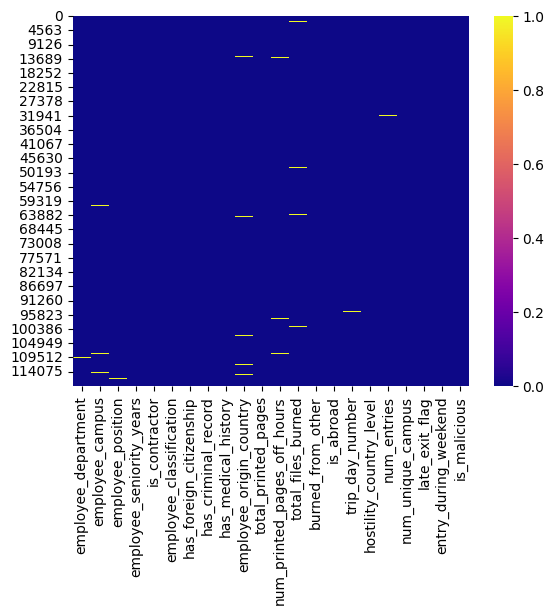

In [91]:
#HeatMap
plt.Figure(figsize= (15 ,8))
sns.heatmap(dt.isnull(), cmap= 'plasma')
plt.show()

**Categorical Features**

In [92]:
dt['employee_department'] = dt['employee_department'].fillna(dt['employee_department'].mode()[0])
dt.isnull().sum()

employee_department              0
employee_campus                632
employee_position              616
employee_seniority_years         0
is_contractor                    0
employee_classification          0
has_foreign_citizenship          0
has_criminal_record              0
has_medical_history              0
employee_origin_country        642
total_printed_pages              0
num_printed_pages_off_hours    597
total_files_burned             599
burned_from_other                0
is_abroad                        0
trip_day_number                636
hostility_country_level          0
num_entries                    641
num_unique_campus                0
late_exit_flag                   0
entry_during_weekend             0
is_malicious                     0
dtype: int64

In [93]:
dt['employee_position'] = dt['employee_position'].fillna(dt['employee_position'].mode()[0])
dt.isnull().sum()

employee_department              0
employee_campus                632
employee_position                0
employee_seniority_years         0
is_contractor                    0
employee_classification          0
has_foreign_citizenship          0
has_criminal_record              0
has_medical_history              0
employee_origin_country        642
total_printed_pages              0
num_printed_pages_off_hours    597
total_files_burned             599
burned_from_other                0
is_abroad                        0
trip_day_number                636
hostility_country_level          0
num_entries                    641
num_unique_campus                0
late_exit_flag                   0
entry_during_weekend             0
is_malicious                     0
dtype: int64

In [94]:
dt['employee_campus'] = dt['employee_campus'].fillna(dt['employee_campus'].mode()[0])
dt.isnull().sum()

employee_department              0
employee_campus                  0
employee_position                0
employee_seniority_years         0
is_contractor                    0
employee_classification          0
has_foreign_citizenship          0
has_criminal_record              0
has_medical_history              0
employee_origin_country        642
total_printed_pages              0
num_printed_pages_off_hours    597
total_files_burned             599
burned_from_other                0
is_abroad                        0
trip_day_number                636
hostility_country_level          0
num_entries                    641
num_unique_campus                0
late_exit_flag                   0
entry_during_weekend             0
is_malicious                     0
dtype: int64

In [95]:
dt['employee_origin_country'] = dt['employee_origin_country'].fillna(dt['employee_origin_country'].mode()[0])
dt.isnull().sum()

employee_department              0
employee_campus                  0
employee_position                0
employee_seniority_years         0
is_contractor                    0
employee_classification          0
has_foreign_citizenship          0
has_criminal_record              0
has_medical_history              0
employee_origin_country          0
total_printed_pages              0
num_printed_pages_off_hours    597
total_files_burned             599
burned_from_other                0
is_abroad                        0
trip_day_number                636
hostility_country_level          0
num_entries                    641
num_unique_campus                0
late_exit_flag                   0
entry_during_weekend             0
is_malicious                     0
dtype: int64

**Numerical Features**

In [96]:
dt['num_entries'] = dt['num_entries'].fillna(dt['num_entries'].mean())
dt.isnull().sum()

employee_department              0
employee_campus                  0
employee_position                0
employee_seniority_years         0
is_contractor                    0
employee_classification          0
has_foreign_citizenship          0
has_criminal_record              0
has_medical_history              0
employee_origin_country          0
total_printed_pages              0
num_printed_pages_off_hours    597
total_files_burned             599
burned_from_other                0
is_abroad                        0
trip_day_number                636
hostility_country_level          0
num_entries                      0
num_unique_campus                0
late_exit_flag                   0
entry_during_weekend             0
is_malicious                     0
dtype: int64

In [97]:
dt['num_printed_pages_off_hours'] = dt['num_printed_pages_off_hours'].fillna(dt['num_printed_pages_off_hours'].mean())
dt.isnull().sum()

employee_department              0
employee_campus                  0
employee_position                0
employee_seniority_years         0
is_contractor                    0
employee_classification          0
has_foreign_citizenship          0
has_criminal_record              0
has_medical_history              0
employee_origin_country          0
total_printed_pages              0
num_printed_pages_off_hours      0
total_files_burned             599
burned_from_other                0
is_abroad                        0
trip_day_number                636
hostility_country_level          0
num_entries                      0
num_unique_campus                0
late_exit_flag                   0
entry_during_weekend             0
is_malicious                     0
dtype: int64

In [98]:
dt['total_files_burned'] = dt['total_files_burned'].fillna(dt['total_files_burned'].mean())
dt.isnull().sum()

employee_department              0
employee_campus                  0
employee_position                0
employee_seniority_years         0
is_contractor                    0
employee_classification          0
has_foreign_citizenship          0
has_criminal_record              0
has_medical_history              0
employee_origin_country          0
total_printed_pages              0
num_printed_pages_off_hours      0
total_files_burned               0
burned_from_other                0
is_abroad                        0
trip_day_number                636
hostility_country_level          0
num_entries                      0
num_unique_campus                0
late_exit_flag                   0
entry_during_weekend             0
is_malicious                     0
dtype: int64

In [99]:
dt['trip_day_number'] = dt['trip_day_number'].fillna(dt['trip_day_number'].mean())
dt.isnull().sum()

employee_department            0
employee_campus                0
employee_position              0
employee_seniority_years       0
is_contractor                  0
employee_classification        0
has_foreign_citizenship        0
has_criminal_record            0
has_medical_history            0
employee_origin_country        0
total_printed_pages            0
num_printed_pages_off_hours    0
total_files_burned             0
burned_from_other              0
is_abroad                      0
trip_day_number                0
hostility_country_level        0
num_entries                    0
num_unique_campus              0
late_exit_flag                 0
entry_during_weekend           0
is_malicious                   0
dtype: int64

In [100]:
dt.duplicated().sum()

np.int64(23)

In [101]:
dt = dt.drop_duplicates (keep='first')

In [102]:
dt.duplicated().sum()

np.int64(0)

# **2. Feature Engineering :**

In [103]:
dt['suspicious_activity_score'] = (dt['num_printed_pages_off_hours'] + dt['total_files_burned'] + dt['late_exit_flag'])
dt.head()

,employee_department,employee_campus,employee_position,employee_seniority_years,is_contractor,employee_classification,has_foreign_citizenship,has_criminal_record,has_medical_history,employee_origin_country,...,burned_from_other,is_abroad,trip_day_number,hostility_country_level,num_entries,num_unique_campus,late_exit_flag,entry_during_weekend,is_malicious,suspicious_activity_score
0,Engineering Department,Campus C,Design Engineer,22,0,2,0,0,0,Georgia,...,0,0,0.0,0,1.0,1,0,1,0,4.0
1,Engineering Department,Campus C,Design Engineer,22,0,2,0,0,0,Georgia,...,0,0,0.0,0,1.0,1,0,0,0,0.0
2,Engineering Department,Campus C,Design Engineer,22,0,2,0,0,0,Georgia,...,0,0,0.0,0,1.0,1,0,0,0,2.0
3,Engineering Department,Campus C,Design Engineer,22,0,2,0,0,0,Georgia,...,0,0,0.0,0,1.0,1,0,0,0,0.0
4,Engineering Department,Campus C,Design Engineer,22,0,2,0,0,0,Georgia,...,0,0,0.0,0,0.0,0,0,0,0,0.0


In [104]:
dt['travel_risk'] = dt['is_abroad'] * dt['hostility_country_level']
dt.head()

,employee_department,employee_campus,employee_position,employee_seniority_years,is_contractor,employee_classification,has_foreign_citizenship,has_criminal_record,has_medical_history,employee_origin_country,...,is_abroad,trip_day_number,hostility_country_level,num_entries,num_unique_campus,late_exit_flag,entry_during_weekend,is_malicious,suspicious_activity_score,travel_risk
0,Engineering Department,Campus C,Design Engineer,22,0,2,0,0,0,Georgia,...,0,0.0,0,1.0,1,0,1,0,4.0,0
1,Engineering Department,Campus C,Design Engineer,22,0,2,0,0,0,Georgia,...,0,0.0,0,1.0,1,0,0,0,0.0,0
2,Engineering Department,Campus C,Design Engineer,22,0,2,0,0,0,Georgia,...,0,0.0,0,1.0,1,0,0,0,2.0,0
3,Engineering Department,Campus C,Design Engineer,22,0,2,0,0,0,Georgia,...,0,0.0,0,1.0,1,0,0,0,0.0,0
4,Engineering Department,Campus C,Design Engineer,22,0,2,0,0,0,Georgia,...,0,0.0,0,0.0,0,0,0,0,0.0,0


In [105]:
dt['off_hour_print_ratio'] = (dt['num_printed_pages_off_hours'] / (dt['total_printed_pages'] + 1))
dt.head()

,employee_department,employee_campus,employee_position,employee_seniority_years,is_contractor,employee_classification,has_foreign_citizenship,has_criminal_record,has_medical_history,employee_origin_country,...,trip_day_number,hostility_country_level,num_entries,num_unique_campus,late_exit_flag,entry_during_weekend,is_malicious,suspicious_activity_score,travel_risk,off_hour_print_ratio
0,Engineering Department,Campus C,Design Engineer,22,0,2,0,0,0,Georgia,...,0.0,0,1.0,1,0,1,0,4.0,0,0.0
1,Engineering Department,Campus C,Design Engineer,22,0,2,0,0,0,Georgia,...,0.0,0,1.0,1,0,0,0,0.0,0,0.0
2,Engineering Department,Campus C,Design Engineer,22,0,2,0,0,0,Georgia,...,0.0,0,1.0,1,0,0,0,2.0,0,0.0
3,Engineering Department,Campus C,Design Engineer,22,0,2,0,0,0,Georgia,...,0.0,0,1.0,1,0,0,0,0.0,0,0.0
4,Engineering Department,Campus C,Design Engineer,22,0,2,0,0,0,Georgia,...,0.0,0,0.0,0,0,0,0,0.0,0,0.0


In [106]:
dt['weird_entry_behavior'] = (dt['num_entries'] * dt['entry_during_weekend'])
dt.head()

,employee_department,employee_campus,employee_position,employee_seniority_years,is_contractor,employee_classification,has_foreign_citizenship,has_criminal_record,has_medical_history,employee_origin_country,...,hostility_country_level,num_entries,num_unique_campus,late_exit_flag,entry_during_weekend,is_malicious,suspicious_activity_score,travel_risk,off_hour_print_ratio,weird_entry_behavior
0,Engineering Department,Campus C,Design Engineer,22,0,2,0,0,0,Georgia,...,0,1.0,1,0,1,0,4.0,0,0.0,1.0
1,Engineering Department,Campus C,Design Engineer,22,0,2,0,0,0,Georgia,...,0,1.0,1,0,0,0,0.0,0,0.0,0.0
2,Engineering Department,Campus C,Design Engineer,22,0,2,0,0,0,Georgia,...,0,1.0,1,0,0,0,2.0,0,0.0,0.0
3,Engineering Department,Campus C,Design Engineer,22,0,2,0,0,0,Georgia,...,0,1.0,1,0,0,0,0.0,0,0.0,0.0
4,Engineering Department,Campus C,Design Engineer,22,0,2,0,0,0,Georgia,...,0,0.0,0,0,0,0,0.0,0,0.0,0.0


In [107]:
print(dt['employee_origin_country'].value_counts())

employee_origin_country
Palestine       50314
Russia           9828
Ukraine          8524
France           6888
Ethiopia         5748
USA              5671
Morocco          3554
UK               2919
Argentina        2775
India            2444
South Africa     2299
Germany          2295
Canada           2031
China            1812
Romania          1791
Brazil           1477
Georgia          1346
Hungary          1160
Poland           1128
Turkey            969
Iran              557
Libya             502
Syria             455
Yemen             398
Qatar             378
Sudan             304
Pakistan          272
Tunisia           249
Kuwait            184
Malaysia          130
North Korea       100
Iraq               89
Name: count, dtype: int64


# **3. Encoding :**

In [108]:

cat_cols = [
    'employee_department',
    'employee_campus',
    'employee_position',
    'employee_origin_country'
]


dt = pd.get_dummies(dt, columns=cat_cols, drop_first=True, dtype=int)


print("--- ALL CURRENT COLUMNS ---")
print(dt.columns.tolist())

display(dt.head(10))

--- ALL CURRENT COLUMNS ---
['employee_seniority_years', 'is_contractor', 'employee_classification', 'has_foreign_citizenship', 'has_criminal_record', 'has_medical_history', 'total_printed_pages', 'num_printed_pages_off_hours', 'total_files_burned', 'burned_from_other', 'is_abroad', 'trip_day_number', 'hostility_country_level', 'num_entries', 'num_unique_campus', 'late_exit_flag', 'entry_during_weekend', 'is_malicious', 'suspicious_activity_score', 'travel_risk', 'off_hour_print_ratio', 'weird_entry_behavior', 'employee_department_Executive Management', 'employee_department_Finance', 'employee_department_Human Resources', 'employee_department_Information Technology', 'employee_department_Legal and Regulation', 'employee_department_Marketing and Business Development', 'employee_department_Operations and Manufacturing', 'employee_department_Project Management', 'employee_department_R&D Department', 'employee_department_Security and Information Security', 'employee_campus_Campus B', 'empl

,employee_seniority_years,is_contractor,employee_classification,has_foreign_citizenship,has_criminal_record,has_medical_history,total_printed_pages,num_printed_pages_off_hours,total_files_burned,burned_from_other,...,employee_origin_country_Russia,employee_origin_country_South Africa,employee_origin_country_Sudan,employee_origin_country_Syria,employee_origin_country_Tunisia,employee_origin_country_Turkey,employee_origin_country_UK,employee_origin_country_USA,employee_origin_country_Ukraine,employee_origin_country_Yemen
0,22,0,2,0,0,0,0,0.0,4.0,0,...,0,0,0,0,0,0,0,0,0,0
1,22,0,2,0,0,0,0,0.0,0.0,0,...,0,0,0,0,0,0,0,0,0,0
2,22,0,2,0,0,0,0,0.0,2.0,0,...,0,0,0,0,0,0,0,0,0,0
3,22,0,2,0,0,0,1,0.0,0.0,0,...,0,0,0,0,0,0,0,0,0,0
4,22,0,2,0,0,0,0,0.0,0.0,0,...,0,0,0,0,0,0,0,0,0,0
5,22,0,2,0,0,0,1,0.0,0.0,0,...,0,0,0,0,0,0,0,0,0,0
6,22,0,2,0,0,0,0,0.0,0.0,0,...,0,0,0,0,0,0,0,0,0,0
7,22,0,2,0,0,0,0,0.0,9.0,0,...,0,0,0,0,0,0,0,0,0,0
8,22,0,2,0,0,0,0,0.0,44.0,0,...,0,0,0,0,0,0,0,0,0,0
9,22,0,2,0,0,0,0,0.0,38.0,0,...,0,0,0,0,0,0,0,0,0,0


# **4. Correlation Analysis :**

In [109]:
# Numerical Features Only For Correlation
num_cols = dt.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Numerical columns:", num_cols)

Numerical columns: ['employee_seniority_years', 'is_contractor', 'employee_classification', 'has_foreign_citizenship', 'has_criminal_record', 'has_medical_history', 'total_printed_pages', 'num_printed_pages_off_hours', 'total_files_burned', 'burned_from_other', 'is_abroad', 'trip_day_number', 'hostility_country_level', 'num_entries', 'num_unique_campus', 'late_exit_flag', 'entry_during_weekend', 'is_malicious', 'suspicious_activity_score', 'travel_risk', 'off_hour_print_ratio', 'weird_entry_behavior', 'employee_department_Executive Management', 'employee_department_Finance', 'employee_department_Human Resources', 'employee_department_Information Technology', 'employee_department_Legal and Regulation', 'employee_department_Marketing and Business Development', 'employee_department_Operations and Manufacturing', 'employee_department_Project Management', 'employee_department_R&D Department', 'employee_department_Security and Information Security', 'employee_campus_Campus B', 'employee_camp

In [110]:
# Correlation With Target
target = 'is_malicious'
corr = dt[num_cols].corr()[target].sort_values(ascending=False)
print("\n=== Correlation with is_malicious (Pearson) ===")
print(corr)


=== Correlation with is_malicious (Pearson) ===
is_malicious                                        1.000000
suspicious_activity_score                           0.454815
total_files_burned                                  0.422528
burned_from_other                                   0.297449
num_printed_pages_off_hours                         0.196503
                                                      ...   
employee_position_Warehouse Manager                -0.041676
employee_department_Project Management             -0.042724
employee_position_Secretary                        -0.043768
employee_department_Operations and Manufacturing   -0.054112
late_exit_flag                                           NaN
Name: is_malicious, Length: 112, dtype: float64


In [111]:
print(dt['late_exit_flag'].value_counts())

late_exit_flag
0    118591
Name: count, dtype: int64


In [112]:
# Spearman ( Better For Non-linear Relationships)
spearman_corr = dt[num_cols].corr(method='spearman')[target].sort_values(ascending=False)
print("\n=== Spearman Correlation with is_malicious ===")
print(spearman_corr)


=== Spearman Correlation with is_malicious ===
is_malicious                                        1.000000
burned_from_other                                   0.297449
suspicious_activity_score                           0.212370
total_files_burned                                  0.198930
employee_origin_country_China                       0.115252
                                                      ...   
employee_position_Warehouse Manager                -0.041676
employee_department_Project Management             -0.042724
employee_position_Secretary                        -0.043768
employee_department_Operations and Manufacturing   -0.054112
late_exit_flag                                           NaN
Name: is_malicious, Length: 112, dtype: float64


## **--> Visualization**

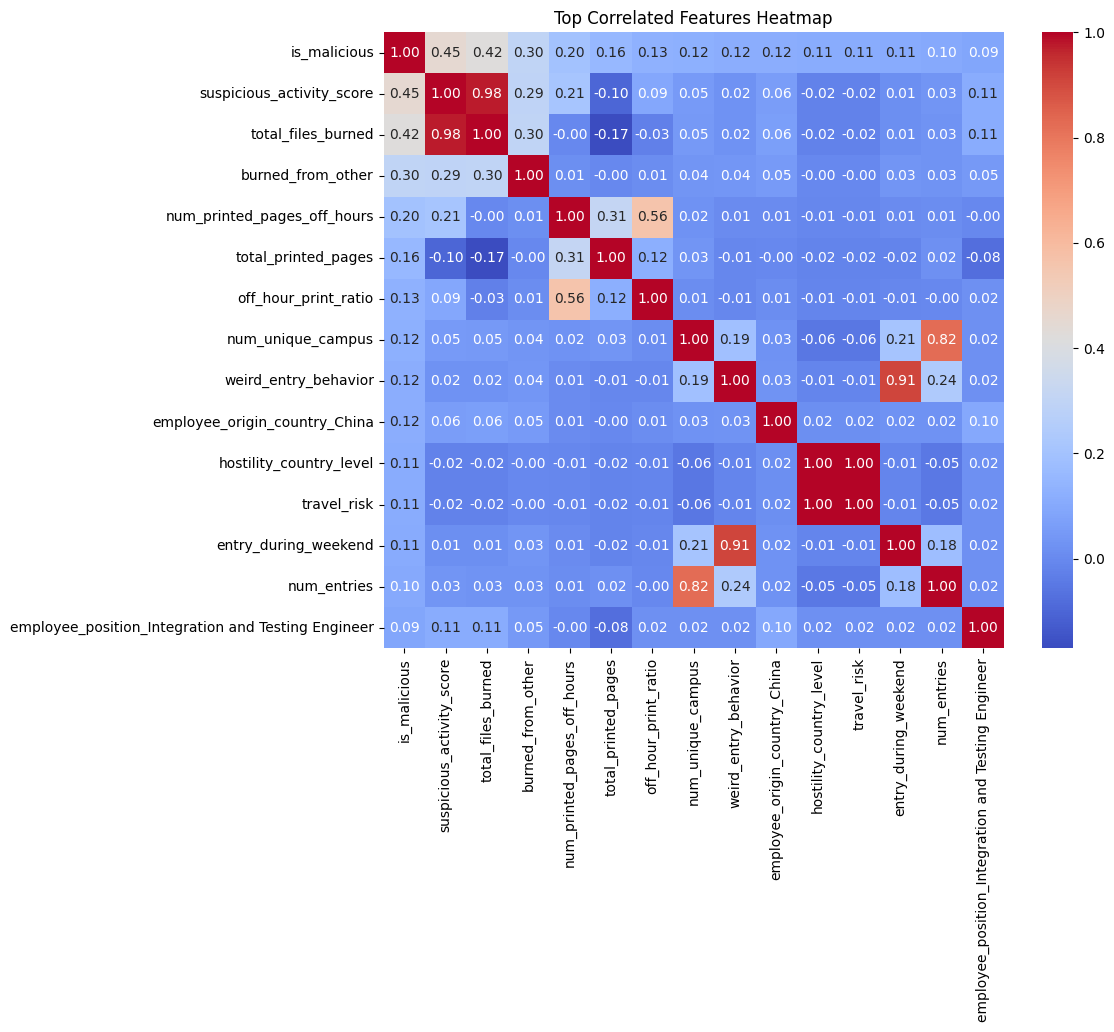

In [113]:
top_features = corr.abs().sort_values(ascending=False).head(15).index

plt.figure(figsize=(10,8))

sns.heatmap(
    dt[top_features].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Top Correlated Features Heatmap')
plt.show()

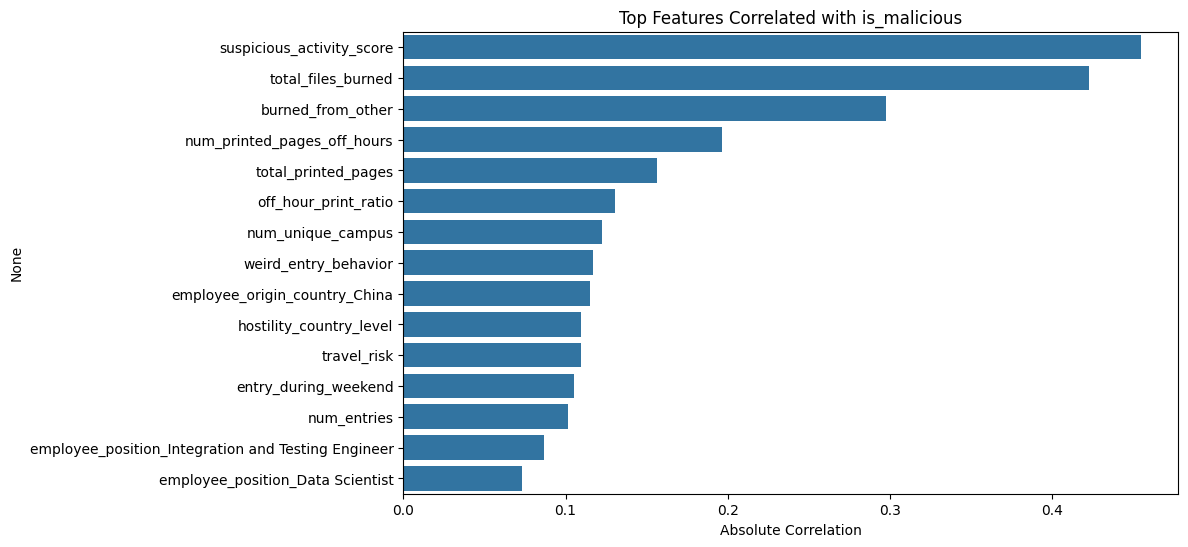

In [114]:
# Top Correlations Bar Plot
top_corr = corr.drop(target).abs().sort_values(ascending=False).head(15)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_corr.values, y=top_corr.index)
plt.title('Top Features Correlated with is_malicious')
plt.xlabel('Absolute Correlation')
plt.show()

# **5. Feature Selection :**

In [115]:
X = dt.drop(['is_malicious', 'late_exit_flag'], axis=1)
y = dt['is_malicious']

In [116]:
X

,employee_seniority_years,is_contractor,employee_classification,has_foreign_citizenship,has_criminal_record,has_medical_history,total_printed_pages,num_printed_pages_off_hours,total_files_burned,burned_from_other,...,employee_origin_country_Russia,employee_origin_country_South Africa,employee_origin_country_Sudan,employee_origin_country_Syria,employee_origin_country_Tunisia,employee_origin_country_Turkey,employee_origin_country_UK,employee_origin_country_USA,employee_origin_country_Ukraine,employee_origin_country_Yemen
0,22,0,2,0,0,0,0,0.0,4.0,0,...,0,0,0,0,0,0,0,0,0,0
1,22,0,2,0,0,0,0,0.0,0.0,0,...,0,0,0,0,0,0,0,0,0,0
2,22,0,2,0,0,0,0,0.0,2.0,0,...,0,0,0,0,0,0,0,0,0,0
3,22,0,2,0,0,0,1,0.0,0.0,0,...,0,0,0,0,0,0,0,0,0,0
4,22,0,2,0,0,0,0,0.0,0.0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118609,2,0,1,0,0,0,95,0.0,0.0,0,...,0,0,0,0,0,0,0,0,0,0
118610,2,0,1,0,0,0,5,0.0,0.0,0,...,0,0,0,0,0,0,0,0,0,0
118611,2,0,1,0,0,0,64,0.0,0.0,0,...,0,0,0,0,0,0,0,0,0,0
118612,2,0,1,0,0,0,21,0.0,0.0,0,...,0,0,0,0,0,0,0,0,0,0


In [117]:
X_encoded = X.copy()

In [118]:
cols_to_drop = [
    "total_files_burned", 
    "hostility_country_level", 
    "weird_entry_behavior", 
    "off_hour_print_ratio"
]
X_encoded = X_encoded.drop(columns=[col for col in cols_to_drop if col in X_encoded.columns])

In [119]:
# 1. Mutual Information ( For Classification )
mi_scores = mutual_info_classif(X_encoded, y, random_state=42)
mi_scores = pd.Series(mi_scores, index=X_encoded.columns).sort_values(ascending=False)
print(mi_scores.head(15))

suspicious_activity_score                           0.075327
total_printed_pages                                 0.023705
num_unique_campus                                   0.022669
num_entries                                         0.015220
burned_from_other                                   0.014391
employee_origin_country_Palestine                   0.012528
employee_classification                             0.011907
num_printed_pages_off_hours                         0.010728
employee_seniority_years                            0.009725
employee_campus_Campus C                            0.007394
employee_campus_Campus B                            0.005787
employee_department_Operations and Manufacturing    0.004337
employee_department_R&D Department                  0.003972
employee_origin_country_China                       0.003909
entry_during_weekend                                0.003265
dtype: float64


In [120]:
# 2. ANOVA F-value ( For Numerical Features )
f_scores = SelectKBest(score_func=f_classif, k="all").fit(X_encoded, y)

f_scores_df = pd.DataFrame({
    'Feature': X_encoded.columns,
    'F_Score': f_scores.scores_
}).sort_values(by='F_Score', ascending=False)

print(f_scores_df.head(15))

                                              Feature       F_Score
14                          suspicious_activity_score  30928.727965
8                                   burned_from_other  11510.655428
7                         num_printed_pages_off_hours   4763.048037
6                                 total_printed_pages   2976.152472
12                                  num_unique_campus   1811.089505
77                      employee_origin_country_China   1596.439742
15                                        travel_risk   1437.967030
13                               entry_during_weekend   1325.034607
11                                        num_entries   1231.631379
54  employee_position_Integration and Testing Engi...    892.642148
40                   employee_position_Data Scientist    634.752503
49              employee_position_Head of Engineering    390.448746
93                     employee_origin_country_Poland    351.569086
22   employee_department_Operations and Manufact

# **6-Train/Test Split & Scaling**

In [121]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [122]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [123]:
print(f"For Train Data: {len(X_train)}, \nFor Test Data: {len(X_test)}")

For Train Data: 94872, 
For Test Data: 23719


# **Logistic Regression**

In [124]:
# 1. Initialize and Train the Logistic Regression model
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced')

# 2. Train the model
log_reg.fit(X_train, y_train)

# 3. Make predictions on the test set
y_pred_lr = log_reg.predict(X_test)
y_prob_lr = log_reg.predict_proba(X_test)[:, 1] # Probabilities for ROC curve

In [125]:
auc_lr = roc_auc_score(y_test, y_prob_lr)

In [126]:
# 4. Display Evaluation Metrics
print("--- Logistic Regression Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"AUC-ROC:  {auc_lr:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

--- Logistic Regression Performance ---
Accuracy: 0.8777
AUC-ROC:  0.9273

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.88      0.93     22442
           1       0.28      0.81      0.42      1277

    accuracy                           0.88     23719
   macro avg       0.63      0.85      0.67     23719
weighted avg       0.95      0.88      0.90     23719



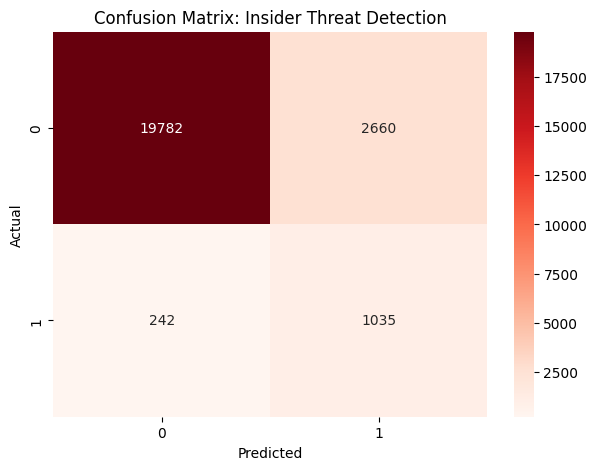

In [127]:
# 5. Visualizing the Confusion Matrix
plt.figure(figsize=(7, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Reds')
plt.title('Confusion Matrix: Insider Threat Detection')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [128]:
# 6. Get Coefficients to see which features are most "dangerous"
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Weight': log_reg.coef_[0]
}).sort_values(by='Weight', ascending=False)

print("\nTop Features Contributing to Threat Detection:")
print(feature_importance.head(10))


Top Features Contributing to Threat Detection:
                                              Feature    Weight
6                                 total_printed_pages  0.713795
16                          suspicious_activity_score  0.461972
10                                          is_abroad  0.439339
8                                  total_files_burned  0.436969
14                                  num_unique_campus  0.405417
96                  employee_origin_country_Palestine  0.368606
81                      employee_origin_country_China  0.328529
44                   employee_position_Data Scientist  0.282378
31                           employee_campus_Campus C  0.281814
49  employee_position_Enterprise Systems Developer...  0.269519


In [129]:
# Training accuracy
train_pred_lr = log_reg.predict(X_train)
train_acc = accuracy_score(y_train, train_pred_lr)

# Test accuracy
test_pred_lr = log_reg.predict(X_test)
test_acc = accuracy_score(y_test, test_pred_lr)

print("Training Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Training Accuracy: 0.8758432414200186
Test Accuracy: 0.877650828449766


# **Decision Tree**

In [130]:
classifier = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=0)
classifier.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

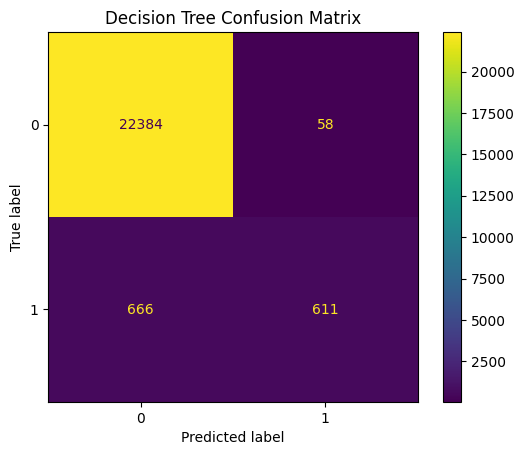

In [131]:
y_pred_dt = classifier.predict(X_test)
y_pred_proba_dt = classifier.predict_proba(X_test)[:, 1]

cm_dt = confusion_matrix(y_test, y_pred_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt)
disp.plot()
plt.title("Decision Tree Confusion Matrix")
plt.show()

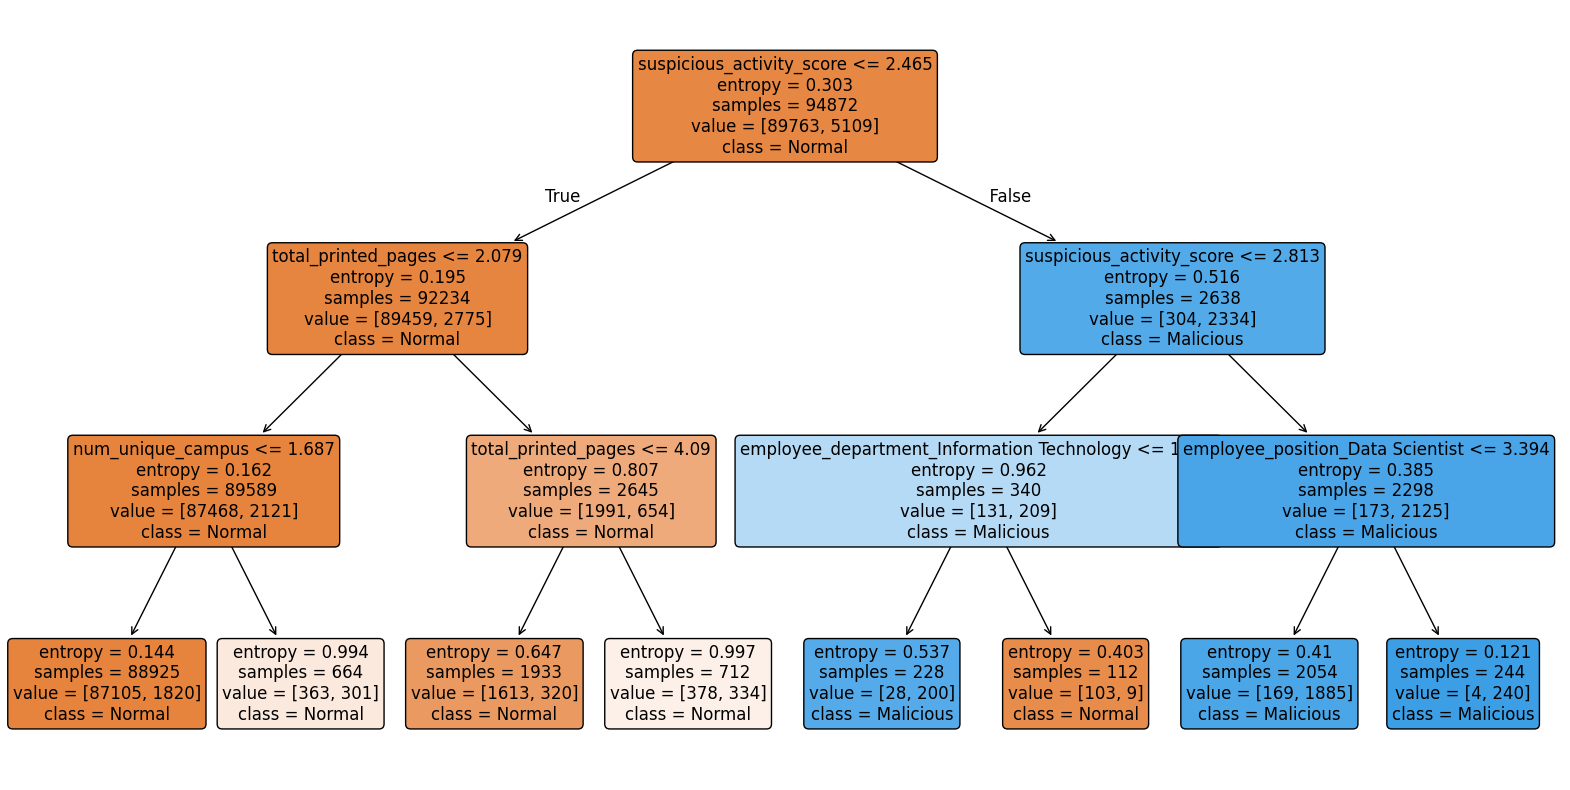

In [132]:

plt.figure(figsize=(20, 10))
tree.plot_tree(classifier, 
               feature_names=X.columns, 
               class_names=['Normal', 'Malicious'], 
               filled=True, 
               rounded=True, 
               fontsize=12)
plt.show()

In [133]:
acc_dt = accuracy_score(y_test, y_pred_dt)
prec_dt = precision_score(y_test, y_pred_dt)
rec_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
auc_dt = roc_auc_score(y_test, y_pred_proba_dt)

In [134]:
print("--- DECISION TREE PERFORMANCE ---")
print(f"Accuracy:  {acc_dt:.4f}")
print(f"Precision: {prec_dt:.4f}")
print(f"Recall:    {rec_dt:.4f}")
print(f"F1-Score:  {f1_dt:.4f}")
print(f"AUC-ROC:   {auc_dt:.4f}")

--- DECISION TREE PERFORMANCE ---
Accuracy:  0.9695
Precision: 0.9133
Recall:    0.4785
F1-Score:  0.6280
AUC-ROC:   0.8084


In [135]:
# Training accuracy
train_pred_dt = classifier.predict(X_train)
train_acc = accuracy_score(y_train, train_pred_dt)

# Test accuracy
test_pred_dt = classifier.predict(X_test)
test_acc = accuracy_score(y_test, test_pred_dt)

print("Training Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Training Accuracy: 0.9685365545155578
Test Accuracy: 0.9694759475525949


# **Random Forest**

In [136]:
RF_ml = RandomForestClassifier(random_state=42)
RF_ml.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [137]:
y_pred_rf = RF_ml.predict(X_test)
y_pred_proba_rf = RF_ml.predict_proba(X_test)[:, 1]

In [138]:
accuracy = accuracy_score(y_test, y_pred_rf)
precision = precision_score(y_test, y_pred_rf)
recall = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_pred_proba_rf)

print("Accuracy =", accuracy)
print("Precision =", precision)
print("Recall =", recall)
print("F1-Score  =", f1_rf)
print(f"AUC-ROC:   {auc_rf:.4f}")

Accuracy = 0.9709093975294069
Precision = 0.7451963241436925
Recall = 0.6985121378230227
F1-Score  = 0.7210994341147938
AUC-ROC:   0.9814


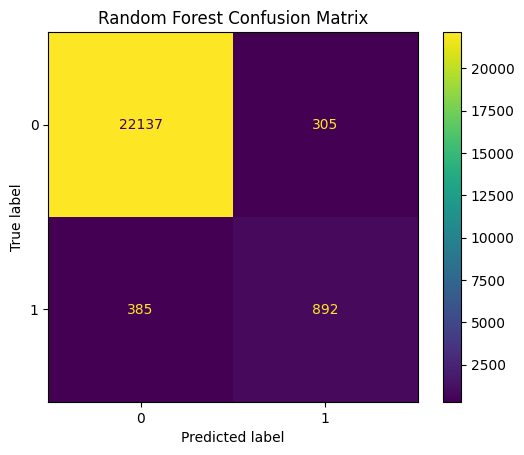

In [139]:
ConfMat_rf = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=ConfMat_rf)
disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

In [140]:
# Training accuracy
train_pred_rf = RF_ml.predict(X_train)
train_acc = accuracy_score(y_train, train_pred_rf)

# Test accuracy
test_pred_rf = RF_ml.predict(X_test)
test_acc = accuracy_score(y_test, test_pred_rf)

print("Training Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Training Accuracy: 0.9969643308879332
Test Accuracy: 0.9709093975294069


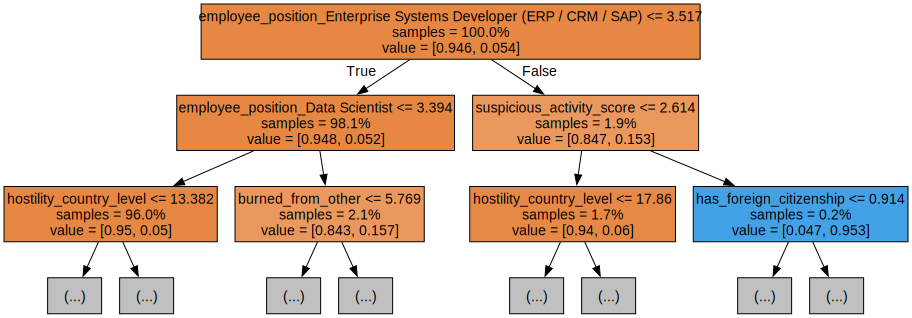

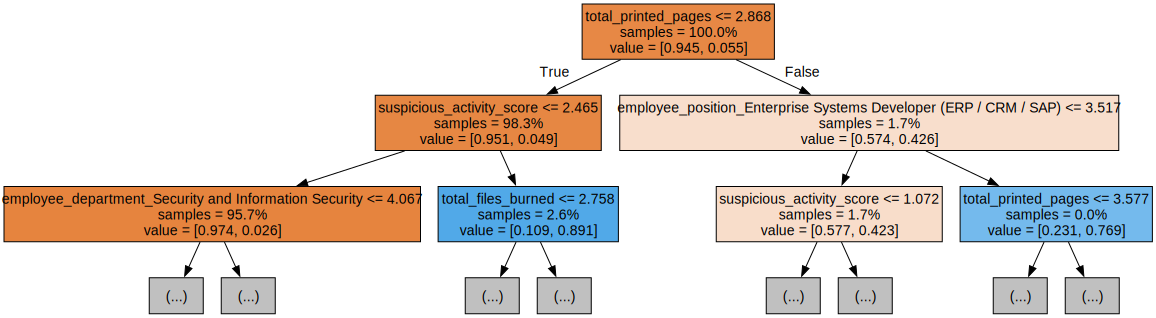

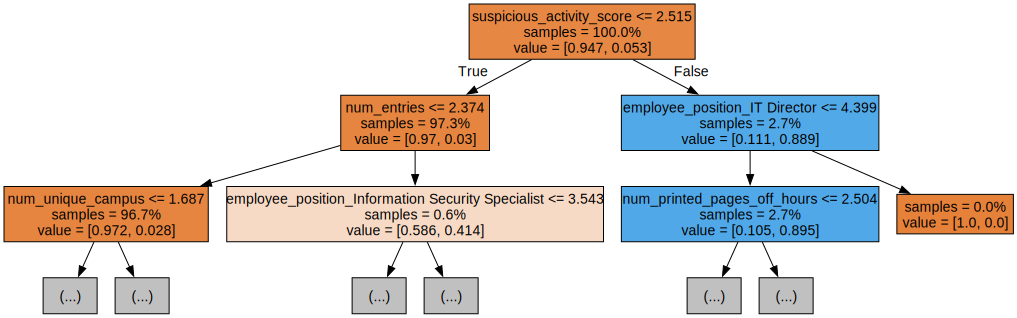

In [141]:
for i in range(3):

    tree_model = RF_ml.estimators_[i]

    dot_data = export_graphviz(
        tree_model,
        feature_names=X.columns,
        filled=True,
        max_depth=2,
        impurity=False,
        proportion=True
    )

    graph = graphviz.Source(dot_data)

    display(graph)

In [142]:
#Hyperparameters tuning
param_dist = {
    'n_estimators': randint(50, 500),
    'max_depth': randint(1, 20)
}
RF_ml = RandomForestClassifier(random_state=42)
rand_search = RandomizedSearchCV(
    RF_ml,
    param_distributions=param_dist,
    n_iter=5,
    cv=5
)
rand_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': <scipy.stats....001F78000A8B0>, 'n_estimators': <scipy.stats....001F783726E90>}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default va

In [143]:
best_RF = rand_search.best_estimator_
print("Best Hyperparameters:")
print(rand_search.best_params_)

Best Hyperparameters:
{'max_depth': 17, 'n_estimators': 125}


In [144]:
y_pred_best = best_RF.predict(X_test)
y_pred_proba_best = best_RF.predict_proba(X_test)[:, 1]

In [145]:
accuracy = accuracy_score(y_test, y_pred_best)
precision = precision_score(y_test, y_pred_best)
recall = recall_score(y_test, y_pred_best)
f1_best = f1_score(y_test, y_pred_best)
auc_best = roc_auc_score(y_test, y_pred_proba_best)

print("Accuracy =", accuracy)
print("Precision =", precision)
print("Recall =", recall)
print("F1-Score  =", f1_best)
print(f"AUC-ROC:   {auc_best:.4f}")

Accuracy = 0.9732282136683671
Precision = 0.8776470588235294
Recall = 0.5841816758026624
F1-Score  = 0.7014574518100611
AUC-ROC:   0.9764


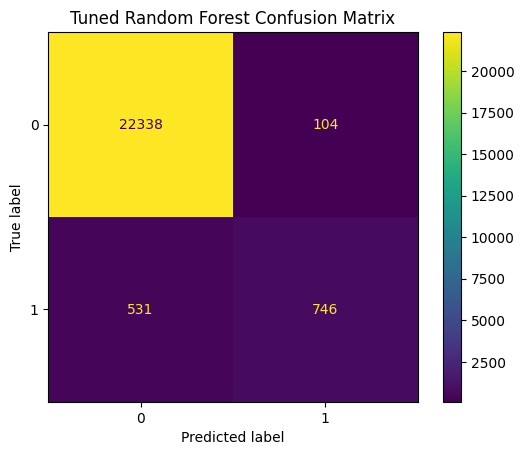

In [146]:
ConfMat_best = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=ConfMat_best)
disp.plot()
plt.title("Tuned Random Forest Confusion Matrix")
plt.show()

# **KNN**

In [147]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [148]:
y_pred_knn = knn.predict(X_test)
y_pred_proba_knn = knn.predict_proba(X_test)[:, 1]

In [149]:
print("training set score: {:.4f}".format(knn.score(X_train, y_train)))
print("test set score: {:.4f}".format(accuracy_score(y_test, y_pred_knn)))

training set score: 0.9809
test set score: 0.9723


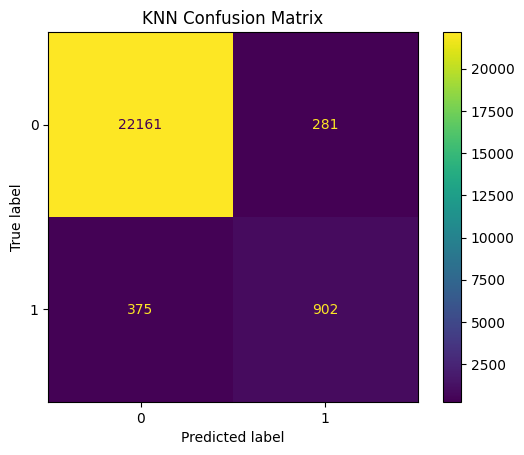

In [150]:
cm_knn = confusion_matrix(y_test, y_pred_knn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn)
disp.plot()
plt.title("KNN Confusion Matrix")
plt.show()

In [151]:
acc_knn = accuracy_score(y_test, y_pred_knn)
prec_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)
auc_knn = roc_auc_score(y_test, y_pred_proba_knn)


In [152]:
print("--- KNN PERFORMANCE ---")
print(f"Accuracy:  {acc_knn:.4f}")
print(f"Precision: {prec_knn:.4f}")
print(f"Recall:    {recall_knn:.4f}")
print(f"F1-Score:  {f1_knn:.4f}")
print(f"AUC-ROC:   {auc_knn:.4f}")

--- KNN PERFORMANCE ---
Accuracy:  0.9723
Precision: 0.7625
Recall:    0.7063
F1-Score:  0.7333
AUC-ROC:   0.9639


# **SVM**

In [153]:
# 1. Initialize the SVM Classifier
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)

In [154]:
# 2. Train the model using the scaled training data
print("Training SVM model... please wait.")
svm_model.fit(X_train, y_train)

# 3. Make predictions on the test set
y_pred_svm = svm_model.predict(X_test)

Training SVM model... please wait.


In [155]:
y_score_svm = svm_model.decision_function(X_test) 
auc_svm = roc_auc_score(y_test, y_score_svm)

In [156]:
# 4. Evaluation and Results
print("\n--- SVM Model Evaluation ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"AUC-ROC Score:  {auc_svm:.4f}")
# Detailed report: Precision, Recall, F1-score
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))



--- SVM Model Evaluation ---
Accuracy Score: 0.9736
AUC-ROC Score:  0.9763

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99     22442
           1       0.85      0.62      0.72      1277

    accuracy                           0.97     23719
   macro avg       0.91      0.81      0.85     23719
weighted avg       0.97      0.97      0.97     23719



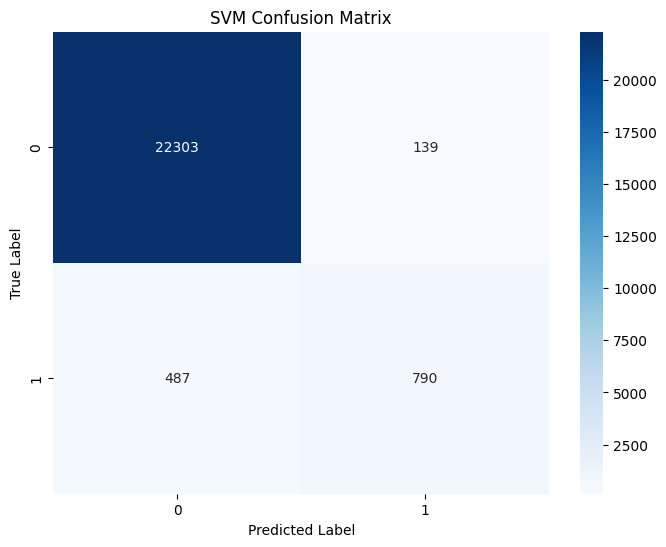

In [157]:
# 5. Visualizing the Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('SVM Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [158]:
# Training accuracy
train_pred_svm = svm_model.predict(X_train)
train_acc = accuracy_score(y_train, train_pred_svm)

# Test accuracy
test_pred_svm = svm_model.predict(X_test)
test_acc = accuracy_score(y_test, test_pred_svm)

print("Training Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Training Accuracy: 0.9761468083312252
Test Accuracy: 0.9736076563092879


# **XGBoosting**

In [159]:
xgb_ml = XGBClassifier()
xgb_ml.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [160]:
y_pred_xgb = xgb_ml.predict(X_test)
y_pred_proba_xgb = xgb_ml.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred_xgb)
precision = precision_score(y_test, y_pred_xgb)
recall = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)

print("Accuracy =", accuracy)
print("Precision =", precision)
print("Recall =", recall)
print("F1-Score  =", f1_xgb)
print(f"AUC-ROC:   {auc_xgb:.4f}")

Accuracy = 0.9746195033517433
Precision = 0.8157156220767072
Recall = 0.682850430696946
F1-Score  = 0.7433930093776641
AUC-ROC:   0.9849


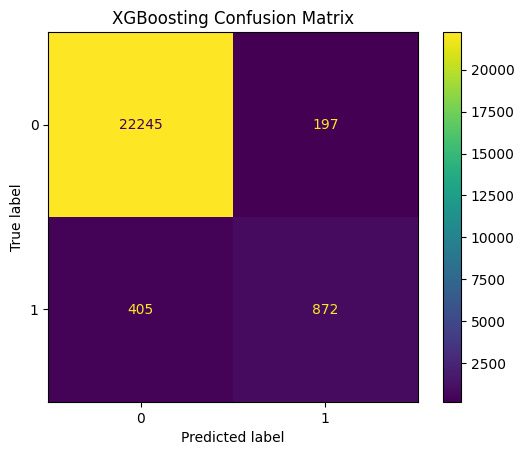

In [161]:
ConfMat_xgb = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=ConfMat_xgb)
disp.plot()
plt.title("XGBoosting Confusion Matrix")
plt.show()

In [162]:
# Training accuracy
train_pred_xgb = xgb_ml.predict(X_train)
train_acc = accuracy_score(y_train, train_pred_xgb)

# Test accuracy
test_pred_xgb = xgb_ml.predict(X_test)
test_acc = accuracy_score(y_test, test_pred_xgb)

print("Training Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Training Accuracy: 0.9809322033898306
Test Accuracy: 0.9746195033517433


# **Stacking**

In [163]:
base_models = [
    ('rf', RandomForestClassifier(n_estimators=100)),
    ('knn', KNeighborsClassifier(n_neighbors=5)),
    ('xgb', XGBClassifier(use_label_encoder=False, eval_metric='logloss'))
]
final_model = LogisticRegression()

In [ ]:
stack_ml = StackingClassifier(
    estimators= base_models,
    final_estimator= final_model,
    cv = 5
)
stack_ml.fit(X_train, y_train)

c:\Users\hp\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:03:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
y_pred_stack = stack_ml.predict(X_test)
y_pred_proba_stack = stack_ml.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred_stack)
precision = precision_score(y_test, y_pred_stack)
recall = recall_score(y_test, y_pred_stack)
f1_stack = f1_score(y_test, y_pred_stack)
auc_stack = roc_auc_score(y_test, y_pred_proba_stack)

print("Accuracy =", accuracy)
print("Precision =", precision)
print("Recall =", recall)
print("F1-Score  =", f1_stack)
print(f"AUC-ROC:   {auc_stack:.4f}")

Accuracy = 0.9750832665795354
Precision = 0.828544061302682
Recall = 0.6773688332028192
F1-Score  = 0.7453683757001293
AUC-ROC:   0.9858


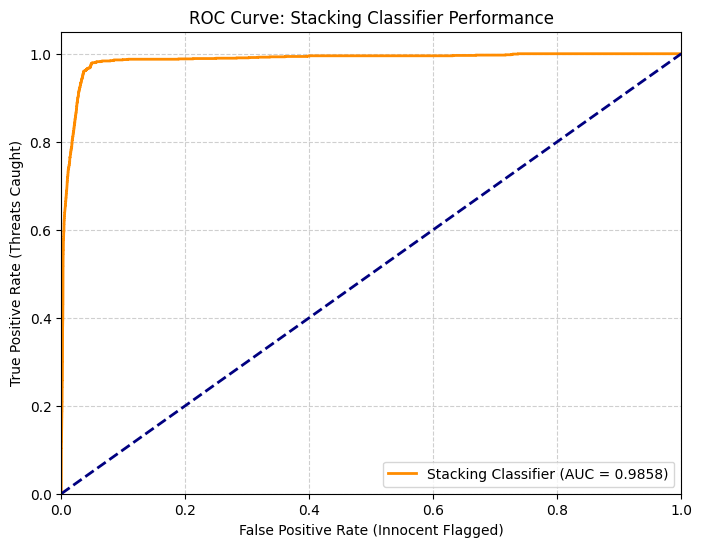

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 1. Calculate the ROC curve points for your final Stacking Classifier
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_stack)
roc_auc = auc(fpr, tpr)

# 2. Plot the ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Stacking Classifier (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Random guess baseline

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Innocent Flagged)')
plt.ylabel('True Positive Rate (Threats Caught)')
plt.title('ROC Curve: Stacking Classifier Performance')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.6)

# 3. Save the image to your computer for LinkedIn!
plt.savefig("stacking_model_roc_curve.png", dpi=300)
plt.show()